In [3]:
import os
import sys
# add the 'src' directory as one where we can import modules
PROJ_ROOT = os.path.join(os.pardir)
src_dir = os.path.join(PROJ_ROOT, 'src')
sys.path.append(src_dir)

print(os.getcwd())
print(sys.path)

import IPython.extensions.autoreload
%load_ext autoreload
%autoreload 2

# import my method from the source code
from ingest import data_workflow
from dataset import analyze, detect_elapsed_time_anomalies, resample
import matplotlib.pyplot as plt

c:\Users\Loris Amabile\Documents\c_market\notebooks
['C:\\Users\\Loris Amabile\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\python312.zip', 'C:\\Users\\Loris Amabile\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\DLLs', 'C:\\Users\\Loris Amabile\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib', 'C:\\Users\\Loris Amabile\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none', 'c:\\Users\\Loris Amabile\\Documents\\c_market\\.venv', '', 'c:\\Users\\Loris Amabile\\Documents\\c_market\\.venv\\Lib\\site-packages', 'c:\\Users\\Loris Amabile\\Documents\\c_market\\.venv\\Lib\\site-packages\\win32', 'c:\\Users\\Loris Amabile\\Documents\\c_market\\.venv\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\Loris Amabile\\Documents\\c_market\\.venv\\Lib\\site-packages\\Pythonwin', '..\\src', '..\\src']
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


count                        37058
mean     0 days 00:00:12.466134653
std      0 days 00:01:05.259632025
min         0 days 00:00:01.005000
25%                0 days 00:00:03
50%         0 days 00:00:06.992000
75%         0 days 00:00:09.994000
max         0 days 01:29:01.994000
Name: timestamp_diff_col, dtype: object
---------------- elapsed anomalies : 31198 (expected 0 days 00:00:02) ------------
              measured_at_utc  steam_production_(m3/h)
0   2025-12-14 23:00:00+00:00               675.168389
1   2025-12-14 23:15:00+00:00               405.602544
2   2025-12-14 23:30:00+00:00               762.998687
3   2025-12-14 23:45:00+00:00               922.988580
4   2025-12-15 00:00:00+00:00               350.557155
..                        ...                      ...
509 2025-12-20 06:15:00+00:00               642.592169
510 2025-12-20 06:30:00+00:00               656.394602
511 2025-12-20 06:45:00+00:00               530.893062
512 2025-12-20 07:00:00+00:00               533

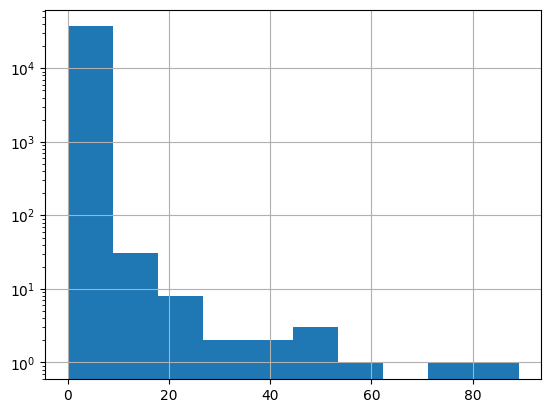

In [39]:
df = data_workflow("inariz")

# include the unit into the main column name
df = df.rename(columns={"Valeur": "steam_production_(m3/h)"})

# for other columns, keep only numerical columns
# set the timestamp as a column with a standard name, not as the index
df = df.drop(columns=["Unité"])


analyze(df)
elapsed_anomalies, expected_delta = detect_elapsed_time_anomalies(df, timestamp_col="measured_at_utc")
# target
df = df[["measured_at_utc", "steam_production_(m3/h)"]] #required, as the data_workflow creates new columns when localizing and converting to utc
df_10min = resample(df, desired_timedelta="10min", aggregate_function="mean")
df_15min = resample(df, desired_timedelta="15min", aggregate_function="mean")

Verify that the average is done correctly between [00:00; 00:15[

In [42]:
import pandas as pd 
df_15min[(df_15min["measured_at_utc"] >= pd.Timestamp(2025, 12, 15, 0, 0, 0, tz="UTC")) & (df_15min["measured_at_utc"] <= pd.Timestamp(2025, 12, 15, 1, 0, 0, tz="UTC"))]

,measured_at_utc,steam_production_(m3/h)
4,2025-12-15 00:00:00+00:00,350.557155
5,2025-12-15 00:15:00+00:00,210.832194
6,2025-12-15 00:30:00+00:00,694.924794
7,2025-12-15 00:45:00+00:00,532.643122
8,2025-12-15 01:00:00+00:00,631.676072


,measured_at_utc,steam_production_(m3/h)
4,2025-12-15 00:00:00+00:00,350.557155
5,2025-12-15 00:15:00+00:00,210.832194
6,2025-12-15 00:30:00+00:00,694.924794
7,2025-12-15 00:45:00+00:00,532.643122
8,2025-12-15 01:00:00+00:00,631.676072


In [46]:
df[(df["measured_at_utc"] >= pd.Timestamp(2025, 12, 15, 0, 15, 0, tz="UTC")) & (df["measured_at_utc"] < pd.Timestamp(2025, 12, 15, 0, 30, 0, tz="UTC"))]["steam_production_(m3/h)"].describe()

count     76.000000
mean     210.832194
std       72.323694
min       62.002769
25%      153.867065
50%      246.758553
75%      258.700127
max      458.215576
Name: steam_production_(m3/h), dtype: float64

In [ ]:
# plot original and resampled timeseries, to check the choice of aggregate_function
import PyQt6
%matplotlib qt
fig, ax = plt.subplots()

ax.plot(df["measured_at_utc"], df["steam_production_(m3/h)"], label="original")
ax.step(df_10min["measured_at_utc"], df_10min["steam_production_(m3/h)"], label="resampled 10 min", where="post")
ax.step(df_15min["measured_at_utc"], df_15min["steam_production_(m3/h)"], label="resampled 15 min", where="post")
ax.set_ylabel("Value")
# ax.set_title(path.name)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

Try simplest forms of prediction

In [ ]:
from predict import simple_copy, copy_median_values

df_copy1day = simple_copy(df_15min, "measured_at_utc", "steam_production_(m3/h)", pd.Timestamp(2025,12,15,0,0,0, tz="UTC"), pd.Timestamp(2025,12,16,0,0,0, tz="UTC"))
df_copy1week = simple_copy(df_15min, "measured_at_utc", "steam_production_(m3/h)", pd.Timestamp(2025,12,15,0,0,0, tz="UTC"), pd.Timestamp(2025,12,20,0,0,0, tz="UTC"))


TEMP verification pour simple_copy

In [ ]:
start = pd.Timestamp(2025,12,15, tz="Europe/Paris").tz_convert("UTC")
print(start)
df_copy1day[df_copy1day["measured_at_utc"]==start]

,measured_at,steam_production_(m3/h)
0,2025-12-14 23:00:00+00:00,675.168389


In [ ]:
df_copy1day.iloc[-100:-90].measured_at_utc.dt.weekday

511    5
512    5
513    5
514    5
515    5
516    5
517    5
518    6
519    6
520    6
Name: measured_at, dtype: int32

In [ ]:
# df_copy1week[df_copy1week.measured_at_utc == start_new_1week]
# df_copy1week.iloc[len(df_15min)-3:len(df_15min)+3]
print(df_copy1week.iloc[len(df_15min)].measured_at_utc.weekday())

start = pd.Timestamp(2025,12,15, tz="Europe/Paris").tz_convert("UTC")

print(df_15min[df_15min.measured_at_utc == start].measured_at_utc.dt.weekday)


6
0    6
Name: measured_at, dtype: int32


temp vérification copy median

In [ ]:

df_median1day = copy_median_values(df_15min, "measured_at_utc", "steam_production_(m3/h)", respect_holidays=False, respect_weekdays=True, respect_time=True, extension="jour")
# df_median1week = copy_median_values(df_15min, "measured_at_utc", "steam_production_(m3/h)", respect_holidaysdaysdays=False, respect_weekdays=True, respect_time=True, extension="semaine")

df_median1day.iloc[len(df_15min)-3:len(df_15min)+3]

,measured_at,steam_production_(m3/h)
511,2025-12-20 06:45:00+00:00,530.893062
512,2025-12-20 07:00:00+00:00,533.215119
513,2025-12-20 07:15:00+00:00,832.717848
514,2025-12-20 07:30:00+00:00,682.966483
515,2025-12-20 07:45:00+00:00,682.966483
516,2025-12-20 08:00:00+00:00,582.585169


copy_median_value copie forcément juste après la fin du df inial
ce que je dois vérifier, c'est si, pour faire la valeur du 2025-12-20 07:30:00+00:00, il a bien pris la mediane des jours et weekdays et créneaux pertinents.